Mean Squared Error: 1524.64
R² Score: 0.0147


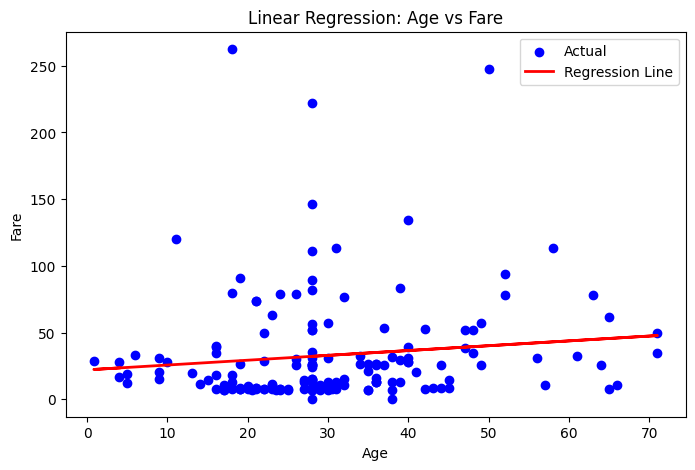

In [2]:
import pandas as pd

# Load and clean dataset (same as Task 1)
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df = df.drop(columns=['Cabin'])
df = df.drop_duplicates()
df['Pclass'] = df['Pclass'].astype('category')
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Predict Fare based on Age (simple example — one feature, one target)
# Drop any remaining missing values in these two columns just in case
reg_df = df[['Age', 'Fare']].dropna()

X = reg_df[['Age']]   # feature (must be 2D)
y = reg_df['Fare']    # target

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")
print(f"R² Score: {r2:.4f}")

# Visualize: actual vs predicted
plt.figure(figsize=(8,5))
plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')
plt.title('Linear Regression: Age vs Fare')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.legend()
plt.show()